# Cancer Subtype Classification Demo Workflow

This notebook demonstrates a compact machine learning workflow for classifying synthetic gene-expression-style samples into breast cancer subtype labels. It is intended as a portfolio project for reviewing data loading, preprocessing, model training, and evaluation code.

**Important:** the data used here is synthetic demo data. It is not real patient data, and this notebook is not a clinical diagnostic tool.

## Why synthetic data?

The project avoids real patient data so the repository can be shared publicly without privacy, access, or data-use concerns. The synthetic dataset is only meant to exercise the code paths and show the modeling workflow end to end.

In [1]:
from pathlib import Path
import os
import sys
import tempfile

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "matplotlib"))

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.pipeline import Pipeline

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import SUBTYPES, align_expression_and_labels, generate_synthetic_demo_dataset
from src.evaluate import calculate_accuracy, calculate_macro_f1
from src.preprocessing import build_preprocessing_pipeline, stratified_train_test_split

## 1. Generate synthetic demo data

The helper below creates sample IDs, gene columns named like `gene_001`, and one subtype label per sample.

In [2]:
RANDOM_SEED = 42

expression_df, labels_df = generate_synthetic_demo_dataset(
    n_samples=80,
    n_genes=12,
    random_state=RANDOM_SEED,
)

demo_df = expression_df.merge(labels_df, on="sample_id", validate="one_to_one")
demo_df.head()

## 2. Class distribution

For this demo, classes are generated with a balanced distribution so the workflow is easy to inspect.

In [3]:
class_counts = labels_df["subtype"].value_counts().reindex(SUBTYPES)
class_counts

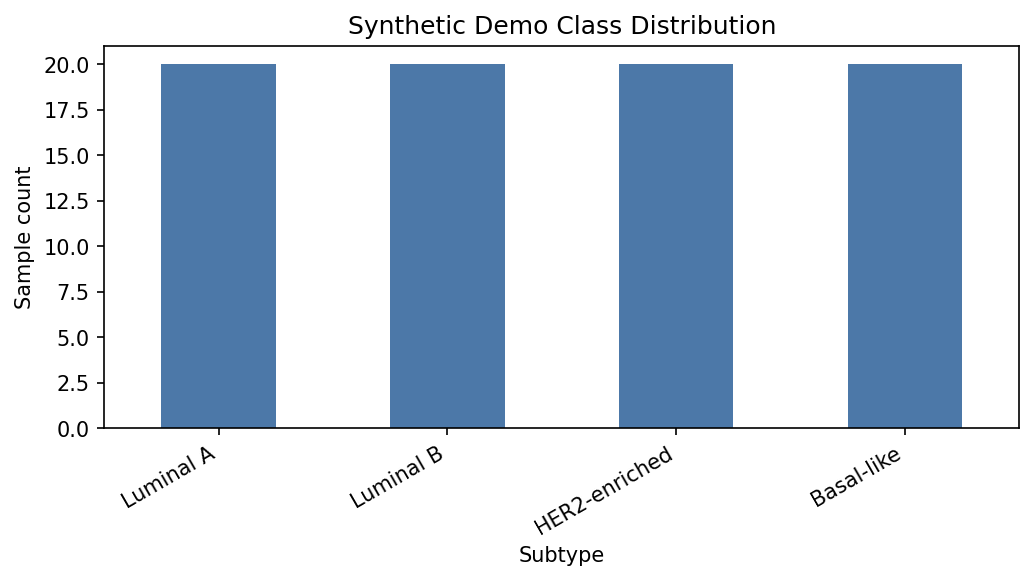

In [4]:
ax = class_counts.plot(kind="bar", color="#4C78A8", figsize=(7, 4))
ax.set_title("Synthetic Demo Class Distribution")
ax.set_xlabel("Subtype")
ax.set_ylabel("Sample count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 3. Preprocessing and training workflow

The workflow aligns expression features with labels, creates a stratified train/test split, and trains two full scikit-learn pipelines. Each saved or evaluated pipeline includes preprocessing plus the classifier.

In [5]:
X, y = align_expression_and_labels(expression_df, labels_df)

X_train, X_test, y_train, y_test = stratified_train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_SEED,
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED),
}

results = []
for model_name, classifier in models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessing", build_preprocessing_pipeline()),
            ("classifier", classifier),
        ]
    )
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    results.append(
        {
            "model": model_name,
            "pipeline": pipeline,
            "y_pred": y_pred,
            "accuracy": calculate_accuracy(y_test, y_pred),
            "macro_f1": calculate_macro_f1(y_test, y_pred),
        }
    )

metrics_df = pd.DataFrame(results).drop(columns=["pipeline", "y_pred"])
metrics_df.sort_values(["macro_f1", "accuracy"], ascending=False)

## 4. Accuracy and macro F1

Accuracy gives the overall fraction of correct predictions. Macro F1 gives each class equal weight, which is useful to inspect performance across subtypes.

In [6]:
best_result = max(results, key=lambda item: (item["macro_f1"], item["accuracy"]))

print(f"Best model: {best_result['model']}")
print(f"Accuracy: {best_result['accuracy']:.3f}")
print(f"Macro F1: {best_result['macro_f1']:.3f}")

Best model: Logistic Regression
Accuracy: 0.950
Macro F1: 0.949


## 5. Confusion matrix

The confusion matrix shows how predicted labels compare with the held-out synthetic test labels.

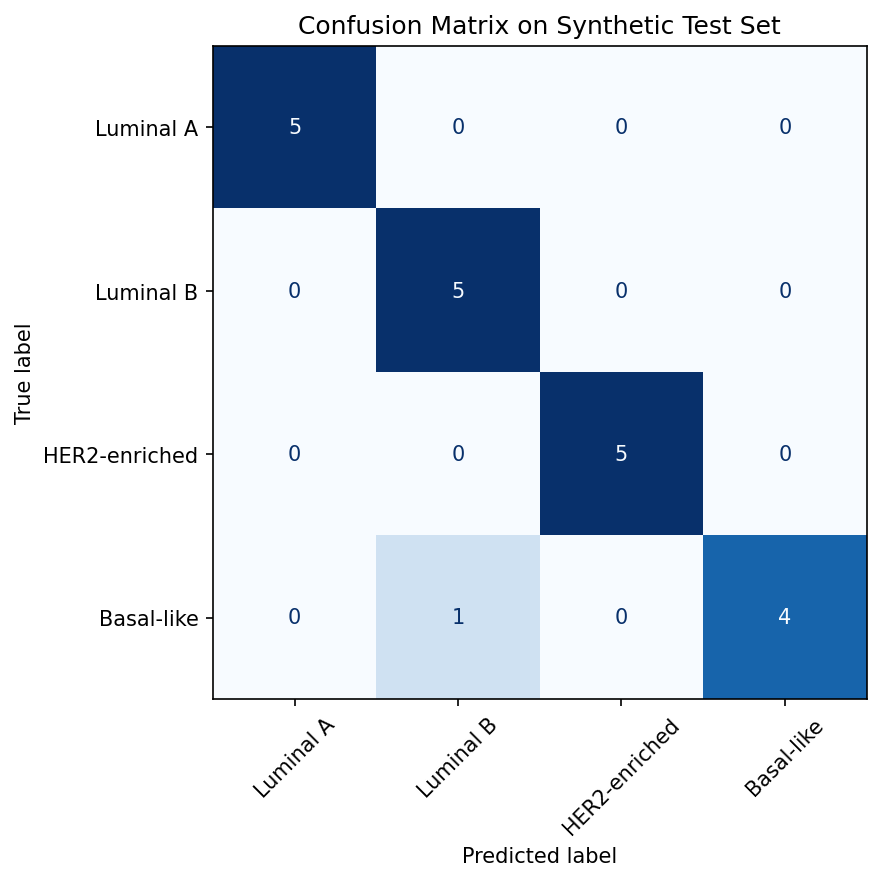

In [7]:
matrix = confusion_matrix(y_test, best_result["y_pred"], labels=SUBTYPES)
display = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=SUBTYPES)

fig, ax = plt.subplots(figsize=(7, 6))
display.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title("Confusion Matrix on Synthetic Test Set")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## What would change with real TCGA BRCA data?

With real TCGA BRCA data, the workflow would need additional steps before modeling:

- Confirm data-access permissions and citation requirements.
- Load a real expression matrix and clinical or molecular subtype labels from approved sources.
- Harmonize sample identifiers across data files.
- Apply domain-appropriate normalization and quality-control checks.
- Use stronger validation, such as cross-validation or an external holdout set.
- Interpret results cautiously with input from relevant biomedical expertise.

Those steps are intentionally outside the synthetic portfolio demo.

## Limitations

- Synthetic data cannot represent the complexity, noise, batch effects, or clinical context of real gene expression data.
- The model scores here only show that the code path works on a toy dataset.
- The subtype labels are demo labels, not clinical determinations.
- This project should be reviewed as a software and machine learning workflow demonstration, not as a medical tool.